#### <u> BOOSTING:</u>

- Boosting is an ensemble learning technique where models are trained sequentially.
- Boosting builds models sequentially to reduce bias (helps underfitting)
- <b>HB LV -> LB LV </b>

To change <b>HB–LV</b> to <b>LB–LV</b> we use <b>*ADDITIVE COMBINING*</B> 

<u>Additive combining means:</u>

Instead of replacing a model, we add a new weak model to the existing one to improve it step by step.

The ensemble prediction is given by:

$$
F(x) = f_1(x) + f_2(x) + f_3(x) + \cdots + f_M(x)
$$
Where:

- $F(x)$ : Final ensemble prediction  
- $f_m(x)$ : Prediction from the $m^{th}$ base model  
- $M$ : Total number of models  
- $x$ : Input feature vector

Why Additive Combining Reduces Bias

- Each weak learner is biased

- But each learner is trained to fix what the previous one couldn’t

- Bias keeps decreasing with each addition


Boosting model is a good choice when:
- Your baseline model is underfitting (low accuracy/high bias) 
- you have tabular structured data and want strong predictive performance with careful tuning
- you can afford sequential training time

the <b>baseline model</b> is a separate, simple model you train and evaluate independently, and then you compare your boosting model (which is an additive ensemble of weak learners) against that baseline’s performance


PREREQUISITE CONCEPTS:
- Weak learner: A model that does only slightly better than random (e.g., a depth‑1 decision tree that splits on just one feature
- Decision stump: A single-split decision tree (max_depth=1), often used as the weak learner in AdaBoost.
- Weighted error: Error rate computed using sample weights, not just counts of misclassified points.
- Sample weight: A non‑negative weight attached to each training example that tells the learner how important that example is; AdaBoost updates these weights each round.

### <u><B> *ADABOOST*</B></U>

- AdaBoost is a boosting technique that combines several weak classifiers(usually very small trees called decision stumps) in sequence to build a strong one.
- Each new model focuses on correcting the mistakes of the previous one until all data is correctly classified or a set number of iterations is reached.

Intuition: how AdaBoost works
Think of m small trees, one after another:

1. Start with all training samples having equal weight.​

$$
W_1(i) = \frac{1}{N}
$$

2. Train Weak Learner 1 (a stump) on these weighted samples.​

3. Compute its weighted error: higher if it misclassifies many important (high‑weight) points.​

$$
\epsilon_t
= \sum_{i=1}^{N} W_t(i)\,
\mathbb{I}\big(h_t(x_i) \neq y_i\big)
$$

4. Give this learner a model weight (higher if its error is low).​

$$
\alpha_t
= \frac{1}{2}\ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)
$$

5. Increase weights of misclassified samples and decrease weights of correctly classified samples.​

$$
W_{t+1}(i)
= \frac{W_t(i)\,\exp\big(-\alpha_t\, y_i\, h_t(x_i)\big)}{Z_t}
$$

Where:

- $W_t(i)$ : Weight of the $i^{th}$ sample at iteration $t$  
- $W_{t+1}(i)$ : Updated weight of the $i^{th}$ sample  
- $\alpha_t$ : Weight of the weak learner at iteration $t$  
- $y_i$ : True label of the $i^{th}$ sample ($+1$ or $-1$)  
- $h_t(x_i)$ : Prediction of the weak learner ($+1$ or $-1$)  
- $\exp(\cdot)$ : Exponential function  
- $Z_t$ : Normalization constant (ensures weights sum to 1)

6. Train Weak Learner 2 on this new weighted data; it is forced to focus more on previously misclassified (“hard”) points.​

$$
H(x)
= \text{sign}\left(
\sum_{t=1}^{T} \alpha_t\, h_t(x)
\right)
$$

7. Repeat for many rounds; the final prediction is the weighted vote of all weak learners

<img src='AdaBoost.png' width=400/>

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

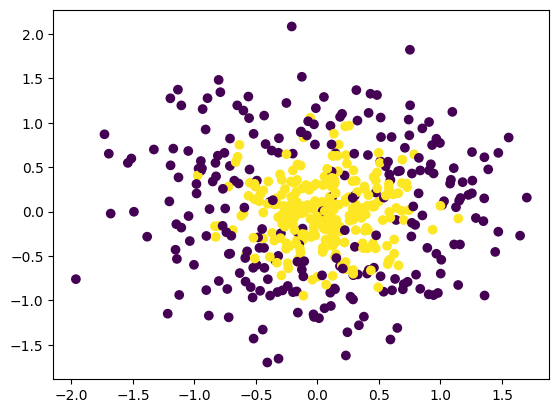

In [2]:
np.random.seed(42)
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y)

In [3]:
#X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

In [5]:
abc=AdaBoostClassifier()

In [6]:
np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.812)

In [7]:
abc.fit(X,y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [8]:
def plot_decision_boundary(clf, X, y):
    plt.figure(figsize=(8, 6))

    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Predict on grid
    X_grid = np.c_[xx1.ravel(), xx2.ravel()]
    y_hat = clf.predict(X_grid)
    y_hat = y_hat.reshape(xx1.shape)

    # Plot decision boundary
    plt.contourf(xx1, xx2, y_hat, cmap="viridis", alpha=0.7)

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")

    plt.title("AdaBoost Classifier Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

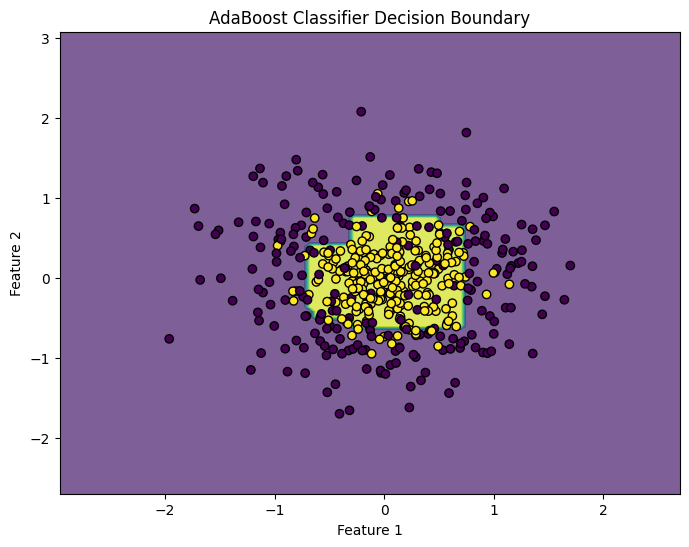

In [9]:
plot_decision_boundary(abc, X, y)


- n_estimators = number of weak learners (iterations) AdaBoost will train
- learning_rate =  scales the contribution of weak learner and controls step size of boosting

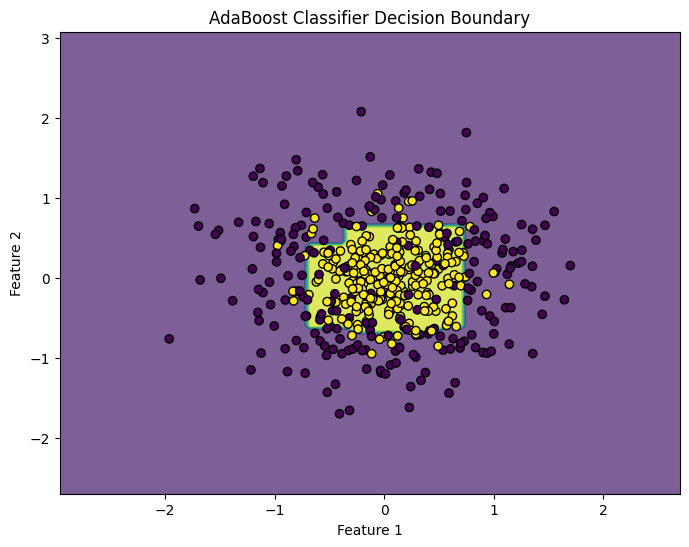

In [10]:
abc=AdaBoostClassifier(n_estimators=100,learning_rate=0.4)
abc.fit(X,y)
plot_decision_boundary(abc,X,y)

#### GridsearchCV

GridSearchCV is an automated way to find the best hyperparameters using cross-validation.

- Tries all combinations of hyperparameters

- Uses Cross-Validation (CV) to evaluate each

- Selects the best performing combination

*KEY CONCEPTS* :

a. Parameter grid -  A dictionary of hyperparameters to try:

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

b. Cross Validation (CV) - It tells GridSearchCV how many times to split the training data.

c. Scoring Metric

In [11]:
from sklearn.model_selection import GridSearchCV

grid= {
'n_estimators': [10,50,100,500],
'learning_rate':[0.0001,0.001,0.01,0.1,1.0],
}
grid_search=GridSearchCV(estimator=AdaBoostClassifier(),
                         param_grid=grid,
                         n_jobs=-1,
                         cv=10,
                         scoring='accuracy'
                        )
grid_result=grid_search.fit(X,y)
print("Best %f using %s" % (grid_result.best_score_,grid_result.best_params_))


Best 0.832000 using {'learning_rate': 0.1, 'n_estimators': 500}


In [12]:
model=grid_search.best_estimator_